Bloc 1 : Imports

In [1]:
import pandas as pd
import numpy as np

# Modèles et Validation
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
)

# Sauvegarde du modèle
import joblib

# Visualisation
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
import matplotlib.pyplot as plt

# Gestion des alertes
import warnings
warnings.filterwarnings(
    "ignore", category=DeprecationWarning
)

Bloc 2 : Fonctions Utilitaires (Helper Functions)

In [2]:
# Helper functions

def train_model(dataset, classifier, target_variable = "Maintenance_Label",
                seed = 0, print_accuracy = False, show_cm = False):
    
    # Drop lines with NaN
    dataset = dataset.dropna()

    # Separate target variable Y from features X
    X = dataset.drop(target_variable, axis=1)
    Y = dataset.loc[:, target_variable]

    # Divide dataset Train set & Test set
    # WARNING : don't forget stratify=Y for classification problems
    X_train, X_test, Y_train, Y_test = train_test_split(
        X, Y, test_size=0.2, random_state=seed, stratify=Y
    )

    # Preprocessing
    preprocessor = StandardScaler()
    X_train = preprocessor.fit_transform(X_train)
    X_test = preprocessor.transform(X_test)

    # Use model passed as argument
    classifier.fit(X_train, Y_train)
    Y_train_pred = classifier.predict(X_train)
    Y_test_pred = classifier.predict(X_test)

    # Print scores
    if print_accuracy:
        print("accuracy on training set : ", accuracy_score(Y_train, Y_train_pred))
        print("accuracy on test set : ", accuracy_score(Y_test, Y_test_pred))
        print()

    train_f1 = f1_score(Y_train, Y_train_pred, average='macro')
    test_f1 = f1_score(Y_test, Y_test_pred, average='macro')
    print("f1-score on training set : ", train_f1)
    print("f1-score on test set : ", test_f1)
    print()

    if show_cm:
        # Visualize confusion matrices
        _, ax = plt.subplots() # Get subplot from matplotlib
        ax.set(title="Confusion Matrix on Train set")
        ConfusionMatrixDisplay.from_estimator(
            classifier, X_train, Y_train, ax=ax
        )
        plt.show()

        _, ax = plt.subplots() # Get subplot from matplotlib
        ax.set(title="Confusion Matrix on Test set")
        ConfusionMatrixDisplay.from_estimator(
            classifier, X_test, Y_test, ax=ax
        )
        plt.show()

    return classifier, train_f1, test_f1

def hyperparameter_tuning(dataset, model, params, target_variable = "Maintenance_Label",
                          seed = 0, print_accuracy = False, show_cm = False):
    # Drop lines with NaN
    dataset = dataset.dropna()

    # Separate target variable Y from features X
    X = dataset.drop(target_variable, axis=1)
    Y = dataset.loc[:, target_variable]

    # Divide dataset Train set & Test set
    # WARNING : don't forget stratify=Y for classification problems
    X_train, X_test, Y_train, Y_test = train_test_split(
        X, Y, test_size=0.2, random_state=seed, stratify=Y
    )

    # Preprocessing
    preprocessor = StandardScaler()
    X_train = preprocessor.fit_transform(X_train)
    X_test = preprocessor.transform(X_test)

    # Grid search
    print('Tuning hyperparameters....')
    print(model)
    print(params)
    classifier = GridSearchCV(model, param_grid=params, cv=3, scoring='f1_macro', verbose=3)
    # cv : the number of folds to be used for CV
    classifier.fit(X_train, Y_train)
    Y_train_pred = classifier.predict(X_train)
    Y_test_pred = classifier.predict(X_test)

    print("Best hyperparameters : ", classifier.best_params_)
    print("Best validation accuracy : ", classifier.best_score_)
    print()

    # Print scores
    if print_accuracy:
        print("accuracy on training set : ", accuracy_score(Y_train, Y_train_pred))
        print("accuracy on test set : ", accuracy_score(Y_test, Y_test_pred))
        print()

    train_f1 = f1_score(Y_train, Y_train_pred, average='macro')
    test_f1 = f1_score(Y_test, Y_test_pred, average='macro')
    print("f1-score on training set : ", train_f1)
    print("f1-score on test set : ", test_f1)
    print()

    if show_cm:
        # Visualize confusion matrices
        _, ax = plt.subplots() 
        ax.set(title="Confusion Matrix on Train set")
        ConfusionMatrixDisplay.from_estimator(classifier, X_train, Y_train, ax=ax)
        plt.show()

        _, ax = plt.subplots() 
        ax.set(title="Confusion Matrix on Test set")
        ConfusionMatrixDisplay.from_estimator(classifier, X_test, Y_test, ax=ax)
        plt.show()

    return classifier, train_f1, test_f1

def make_lagged_dataset(dataset, horizon, target_variable = "Maintenance_Label"):
    feature_names = dataset.drop(target_variable, axis=1).columns.to_list()

    for i in range(horizon):
        dataset_lag = dataset.loc[:, feature_names].shift(i+1)
        dataset_lag.columns = [c + '_' + str(i+1) for c in dataset_lag.columns]
        dataset = pd.concat([dataset, dataset_lag], axis = 1)

    return dataset

Bloc 3 : Préparation des données (Lagged dataset)

In [29]:
# Import dataset
print("Loading dataset...")
dataset = pd.read_csv("wind_turbine_maintenance_data.csv")
print("...Done.")
print()

# Basic stats
print("Number of rows : {}".format(dataset.shape[0]))
print()

print("Display of dataset :")
display(dataset.head())

print("Basics statistics :")
data_desc = dataset.describe(include="all")
display(data_desc)
print()

print("Percentage of missing values :")
display(100 * dataset.isnull().sum() / dataset.shape[0])
print()

print("Class imbalance :")
display(100 * dataset['Maintenance_Label'].value_counts() / dataset.shape[0])

# Filter out turbine 2 (to simple things out)
dataset = dataset.loc[dataset['Turbine_ID'] == 1,:]
dataset = dataset.drop('Turbine_ID', axis = 1)

Loading dataset...
...Done.

Number of rows : 35040

Display of dataset :


,Turbine_ID,Rotor_Speed_RPM,Wind_Speed_mps,Power_Output_kW,Gearbox_Oil_Temp_C,Generator_Bearing_Temp_C,Vibration_Level_mmps,Ambient_Temp_C,Humidity_pct,Maintenance_Label
0,1,15.496714,7.861736,1564.768854,72.615149,73.829233,1.953173,17.896064,67.674347,0
1,1,15.079832,7.840483,1502.222183,62.861035,72.340913,1.976505,11.110395,52.320235,0
2,1,17.559488,8.394233,1512.221917,62.422822,71.998731,2.189488,11.455170,53.644403,0
3,1,15.822545,6.779156,1520.886360,55.201649,68.359070,2.039372,13.692333,61.713683,0
4,1,15.564464,8.025501,1547.319325,68.295953,86.703732,2.214197,10.482082,64.191021,1


Basics statistics :


,Turbine_ID,Rotor_Speed_RPM,Wind_Speed_mps,Power_Output_kW,Gearbox_Oil_Temp_C,Generator_Bearing_Temp_C,Vibration_Level_mmps,Ambient_Temp_C,Humidity_pct,Maintenance_Label
count,35040.000000,35040.000000,35040.000000,35040.000000,35040.000000,35040.000000,35040.000000,35040.000000,35040.000000,35040.000000
mean,1.500000,14.998813,7.991100,1500.087340,65.007705,75.014411,2.001254,10.011707,59.945455,0.247317
std,0.500007,0.996711,1.000523,100.308440,4.987860,4.985797,0.198647,5.033105,9.991139,0.591441
min,1.000000,11.139053,3.801420,1096.556628,44.676878,52.685157,1.194998,-12.021070,15.434405,0.000000
25%,1.000000,14.324117,7.322801,1431.894808,61.662044,71.634222,1.867094,6.618438,53.198579,0.000000
50%,1.500000,14.995670,7.992324,1500.080064,64.991915,75.034723,2.000812,9.981060,59.945151,0.000000
75%,2.000000,15.670454,8.658140,1568.095394,68.353356,78.401443,2.136039,13.411453,66.668883,0.000000
max,2.000000,19.616726,11.824992,1914.789505,86.096832,96.494288,2.842975,34.007573,105.255483,2.000000



Percentage of missing values :


Turbine_ID                  0.0
Rotor_Speed_RPM             0.0
Wind_Speed_mps              0.0
Power_Output_kW             0.0
Gearbox_Oil_Temp_C          0.0
Generator_Bearing_Temp_C    0.0
Vibration_Level_mmps        0.0
Ambient_Temp_C              0.0
Humidity_pct                0.0
Maintenance_Label           0.0
dtype: float64


Class imbalance :


Maintenance_Label
0    83.450342
1     8.367580
2     8.182078
Name: count, dtype: float64

Bloc 4 : Entraînement Baseline

In [4]:
# Dummy classifier
print('--------------------------')
print('Training dummy classifier...')
dummy_clf = DummyClassifier(strategy="most_frequent")
train_model(dataset, dummy_clf)
print('--------------------------')

--------------------------
Training dummy classifier...
f1-score on training set :  0.30328485131316274
f1-score on test set :  0.303256585770587

--------------------------


In [5]:
# Baseline : logistic regression with bare features
print('--------------------------')
print('Training baseline...')
classifier = LogisticRegression(class_weight='balanced', C=np.inf)
train_model(dataset, classifier)
print('--------------------------')

--------------------------
Training baseline...
f1-score on training set :  0.21620529371269773
f1-score on test set :  0.2021016968443857

--------------------------


In [6]:
horizons = [1, 2, 3, 6, 12, 24, 48, 72, 168, 336] # in hours (max: 2 weeks)

# Correction appliquée ici :
performances = pd.DataFrame([]) 

for horizon in horizons:
    print('--------------------------')
    print('horizon: ', horizon)
    dataset_lagged = make_lagged_dataset(dataset, horizon)
    classifier = LogisticRegression(class_weight='balanced', C=np.inf)
    model, train_f1, test_f1 = train_model(dataset_lagged, classifier)
    
    perfs = pd.DataFrame({
        'horizon': [horizon],
        'train_f1': [train_f1],
        'test_f1': [test_f1]
    })
    # Le concat fonctionnera maintenant sans alerte
    performances = pd.concat([performances, perfs], ignore_index=True)

--------------------------
horizon:  1
f1-score on training set :  0.23147552519906833
f1-score on test set :  0.21600751830855344

--------------------------
horizon:  2
f1-score on training set :  0.23355621114758549
f1-score on test set :  0.21662948266804483

--------------------------
horizon:  3
f1-score on training set :  0.23127207305291012
f1-score on test set :  0.21445125530058506

--------------------------
horizon:  6
f1-score on training set :  0.25151527010194635
f1-score on test set :  0.21956488009530808

--------------------------
horizon:  12
f1-score on training set :  0.2688521129489383
f1-score on test set :  0.22746410143016618

--------------------------
horizon:  24
f1-score on training set :  0.2998013096383884
f1-score on test set :  0.23622343868511653

--------------------------
horizon:  48
f1-score on training set :  0.32819630975443315
f1-score on test set :  0.2559246775489575

--------------------------
horizon:  72
f1-score on training set :  0.349800

Bloc 5 : Visualisation et Hyperparamètres

In [7]:
fig = px.line(performances, x = 'horizon', y = ['train_f1', 'test_f1'])
fig.show()

In [30]:
dataset_lagged

,Rotor_Speed_RPM,Wind_Speed_mps,Power_Output_kW,Gearbox_Oil_Temp_C,Generator_Bearing_Temp_C,Vibration_Level_mmps,Ambient_Temp_C,Humidity_pct,Maintenance_Label,Rotor_Speed_RPM_1,...,Ambient_Temp_C_5,Humidity_pct_5,Rotor_Speed_RPM_6,Wind_Speed_mps_6,Power_Output_kW_6,Gearbox_Oil_Temp_C_6,Generator_Bearing_Temp_C_6,Vibration_Level_mmps_6,Ambient_Temp_C_6,Humidity_pct_6
0,15.496714,7.861736,1564.768854,72.615149,73.829233,1.953173,17.896064,67.674347,0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,15.079832,7.840483,1502.222183,62.861035,72.340913,1.976505,11.110395,52.320235,0,15.496714,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,17.559488,8.394233,1512.221917,62.422822,71.998731,2.189488,11.455170,53.644403,0,15.079832,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,15.822545,6.779156,1520.886360,55.201649,68.359070,2.039372,13.692333,61.713683,0,17.559488,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,15.564464,8.025501,1547.319325,68.295953,86.703732,2.214197,10.482082,64.191021,1,15.822545,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17515,15.345209,7.558553,1602.719063,62.154040,77.548350,2.071686,3.084193,59.343218,0,14.660534,...,13.282244,46.441650,16.123815,7.474882,1507.513162,67.196089,76.817648,1.629983,16.007422,57.948466
17516,13.102838,7.415911,1474.837532,75.701727,69.622178,2.168400,2.557220,64.023898,0,15.345209,...,9.122410,56.496619,16.320044,9.616927,1637.503298,67.577562,77.308975,2.150767,13.282244,46.441650
17517,17.009250,6.968089,1558.799927,67.743942,81.103749,1.908795,14.724511,48.268286,0,13.102838,...,14.314883,59.634559,15.421792,9.053527,1689.124482,55.471472,74.130202,2.331813,9.122410,56.496619
17518,14.890098,7.973723,1448.657608,64.630425,71.731050,2.283211,6.967314,56.873958,2,17.009250,...,8.291825,60.387864,15.169414,7.242312,1493.373101,62.151379,71.568672,1.822763,14.314883,59.634559


In [13]:
# Test other model with lagged values (maximal horizon)
classifier = DecisionTreeClassifier(class_weight='balanced')

# Grid of values to be tested
params = {
    "max_depth": [30],
    #"min_samples_leaf": [1, 2, 5, 10],
    #"min_samples_split": [2, 4, 6, 8],
    #"n_estimators": [4, 6, 8, 10]
}

model, train_f1, test_f1 = hyperparameter_tuning(dataset_lagged, classifier, params)

Tuning hyperparameters....
DecisionTreeClassifier(class_weight='balanced')
{'max_depth': [30]}
Fitting 3 folds for each of 1 candidates, totalling 3 fits
[CV 1/3] END ......................max_depth=30;, score=0.324 total time=   0.6s
[CV 2/3] END ......................max_depth=30;, score=0.319 total time=   0.6s
[CV 3/3] END ......................max_depth=30;, score=0.326 total time=   0.7s
Best hyperparameters :  {'max_depth': 30}
Best validation accuracy :  0.3233335990682271

f1-score on training set :  0.9422117906849635
f1-score on test set :  0.3304962739794057



In [11]:
dataset_lagged = make_lagged_dataset(dataset, 6) # 1 week horizon

In [14]:
dataset_lagged

,Rotor_Speed_RPM,Wind_Speed_mps,Power_Output_kW,Gearbox_Oil_Temp_C,Generator_Bearing_Temp_C,Vibration_Level_mmps,Ambient_Temp_C,Humidity_pct,Maintenance_Label,Rotor_Speed_RPM_1,...,Ambient_Temp_C_5,Humidity_pct_5,Rotor_Speed_RPM_6,Wind_Speed_mps_6,Power_Output_kW_6,Gearbox_Oil_Temp_C_6,Generator_Bearing_Temp_C_6,Vibration_Level_mmps_6,Ambient_Temp_C_6,Humidity_pct_6
0,15.496714,7.861736,1564.768854,72.615149,73.829233,1.953173,17.896064,67.674347,0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,15.079832,7.840483,1502.222183,62.861035,72.340913,1.976505,11.110395,52.320235,0,15.496714,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,17.559488,8.394233,1512.221917,62.422822,71.998731,2.189488,11.455170,53.644403,0,15.079832,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,15.822545,6.779156,1520.886360,55.201649,68.359070,2.039372,13.692333,61.713683,0,17.559488,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,15.564464,8.025501,1547.319325,68.295953,86.703732,2.214197,10.482082,64.191021,1,15.822545,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17515,15.345209,7.558553,1602.719063,62.154040,77.548350,2.071686,3.084193,59.343218,0,14.660534,...,13.282244,46.441650,16.123815,7.474882,1507.513162,67.196089,76.817648,1.629983,16.007422,57.948466
17516,13.102838,7.415911,1474.837532,75.701727,69.622178,2.168400,2.557220,64.023898,0,15.345209,...,9.122410,56.496619,16.320044,9.616927,1637.503298,67.577562,77.308975,2.150767,13.282244,46.441650
17517,17.009250,6.968089,1558.799927,67.743942,81.103749,1.908795,14.724511,48.268286,0,13.102838,...,14.314883,59.634559,15.421792,9.053527,1689.124482,55.471472,74.130202,2.331813,9.122410,56.496619
17518,14.890098,7.973723,1448.657608,64.630425,71.731050,2.283211,6.967314,56.873958,2,17.009250,...,8.291825,60.387864,15.169414,7.242312,1493.373101,62.151379,71.568672,1.822763,14.314883,59.634559


In [22]:
# Alternative try: try regularization of the linear model
#classifier = LogisticRegression(class_weight = 'balanced', solver = 'saga',
#                                penalty='elasticnet', l1_ratio=1.0) # Lasso

classifier = DecisionTreeClassifier(class_weight='balanced')

# Grid of values to be tested

params = {
    "max_depth": [30],
    "min_samples_leaf": [1],
    "min_samples_split": [4],
    #"n_estimators": [4, 6, 8, 10]
}

#params = {
#    'C' : [10]
#}

model, train_f1, test_f1 = hyperparameter_tuning(dataset_lagged, classifier, params)

Tuning hyperparameters....
DecisionTreeClassifier(class_weight='balanced')
{'max_depth': [30], 'min_samples_leaf': [1], 'min_samples_split': [4]}
Fitting 3 folds for each of 1 candidates, totalling 3 fits
[CV 1/3] END max_depth=30, min_samples_leaf=1, min_samples_split=4;, score=0.331 total time=   0.6s
[CV 2/3] END max_depth=30, min_samples_leaf=1, min_samples_split=4;, score=0.321 total time=   0.6s
[CV 3/3] END max_depth=30, min_samples_leaf=1, min_samples_split=4;, score=0.328 total time=   0.7s
Best hyperparameters :  {'max_depth': 30, 'min_samples_leaf': 1, 'min_samples_split': 4}
Best validation accuracy :  0.326655828376875

f1-score on training set :  0.9297451987081287
f1-score on test set :  0.3261801727650903



In [25]:
model

,criterion,'gini'
,splitter,'best'
,max_depth,30
,min_samples_split,4
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,'balanced'


In [28]:
dataset_lagged.to_csv("wind_turbine_maintenance_data_engineering.csv")

f1-score on training set :  0.9314532577981147
f1-score on test set :  0.3332005519583608



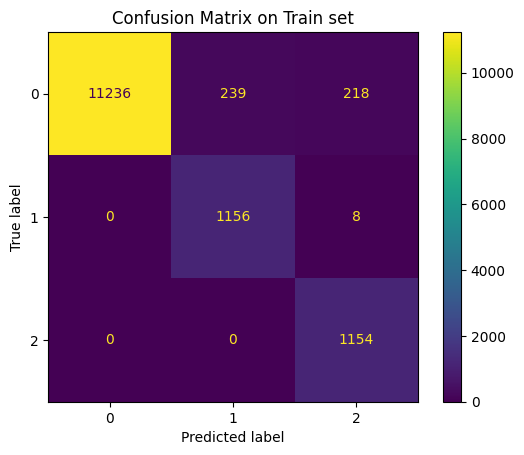

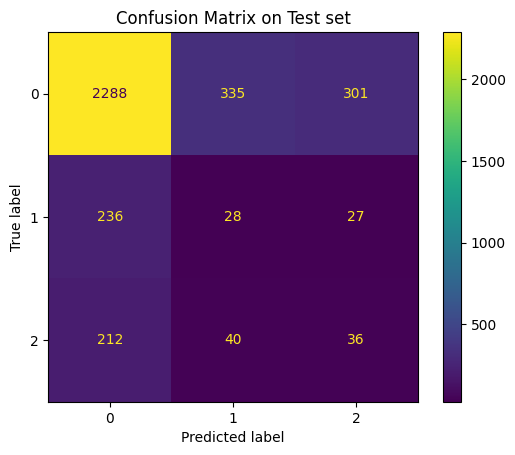

In [24]:
# Retry one version of model
classifier = DecisionTreeClassifier(
    class_weight = 'balanced', 
    max_depth=30,
    min_samples_leaf=1,
    min_samples_split=4,
)

model, train_f1, test_f1 = train_model(dataset_lagged, classifier, show_cm = True)

f1-score on training set :  0.2494005654924962
f1-score on test set :  0.23728267808208428



c:\Users\Juju\anaconda3\envs\projet-final\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge



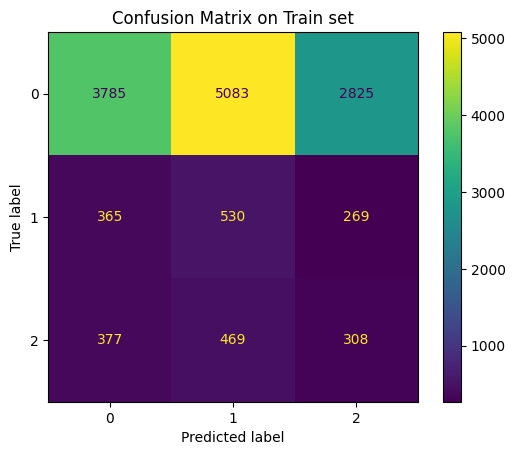

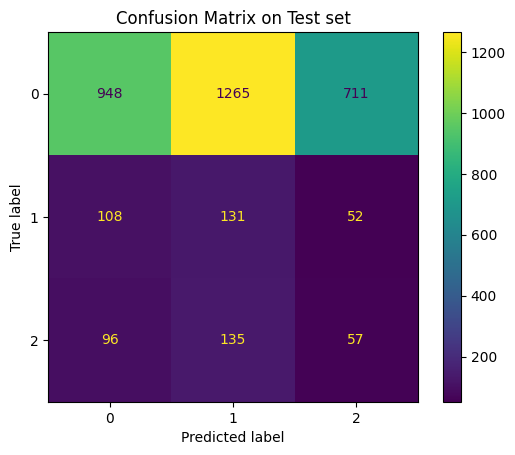

In [16]:
# Retry one version of model
classifier = LogisticRegression(class_weight = 'balanced', solver = 'saga',
                                penalty='elasticnet', l1_ratio=1.0, C = 10,
                                max_iter = 200)

model, train_f1, test_f1 = train_model(dataset_lagged, classifier, show_cm = True)

In [26]:
# --- SAUVEGARDE POUR LE DASHBOARD ---

# Sauvegarde du modèle final
joblib.dump(model, 'model_wind_turbine.pkl')
print("✅ Fichier .pkl généré pour le dashboard.")

✅ Fichier .pkl généré pour le dashboard.


In [31]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import joblib

# Load data
df = pd.read_csv("wind_turbine_maintenance_data.csv")
df = df[df['Turbine_ID'] == 1]

# Just use the 8 raw features
X = df[['Rotor_Speed_RPM', 'Wind_Speed_mps', 'Power_Output_kW', 
         'Gearbox_Oil_Temp_C', 'Generator_Bearing_Temp_C', 
         'Vibration_Level_mmps', 'Ambient_Temp_C', 'Humidity_pct']]
y = df['Maintenance_Label']

# Split & train
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0, stratify=y)

model = DecisionTreeClassifier(class_weight='balanced', max_depth=30)
model.fit(X_train, y_train)

# Save
joblib.dump(model, "model_simple.pkl")
print(f"Model saved! Accuracy: {model.score(X_test, y_test):.2%}")

Model saved! Accuracy: 65.24%


In [32]:
import joblib
model = joblib.load("turbine1_lastmodel.pkl")
print(f"Expected features: {model.n_features_in_}")
print(f"Model type: {type(model)}")

c:\Users\Juju\anaconda3\envs\projet-final\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning:

Trying to unpickle estimator DecisionTreeClassifier from version 1.6.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations

c:\Users\Juju\anaconda3\envs\projet-final\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning:

Trying to unpickle estimator RandomForestClassifier from version 1.6.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations

c:\Users\Juju\anaconda3\envs\projet-final\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning:

Trying to unpickle estimator StandardScaler from version 1.6.1 when using vers

AttributeError: 'dict' object has no attribute 'n_features_in_'